In [1]:
import pandas as pd

In [ ]:
df = pd.read_csv(r'C:\Users\araba\Downloads\retail_pricing_project\data\online_retail_II.csv', encoding='ISO-8859-1')

In [ ]:
import os

In [6]:
print("Current Working Directory:",os.getcwd())

Current Working Directory: C:\Users\araba


In [23]:
clean_data_df = df[df['Quantity'] > 0].copy()

In [24]:
clean_data_df.shape

(1044421, 8)

In [25]:
clean_data_df = clean_data_df[clean_data_df['Price'] > 0]

In [26]:
clean_data_df.shape

(1041671, 8)

In [27]:
print("Minimum Quantity:", clean_data_df['Quantity'].min())

Minimum Quantity: 1


In [28]:
clean_data_df['InvoiceDate'] = pd.to_datetime(clean_data_df['InvoiceDate'])

In [29]:
clean_data_df['Month'] = clean_data_df['InvoiceDate'].dt.month

In [30]:
clean_data_df['DayOfWeek'] = clean_data_df['InvoiceDate'].dt.dayofweek

In [31]:
clean_data_df[['InvoiceDate', 'Month', 'DayOfWeek', 'StockCode', 'Price',]].head()

,InvoiceDate,Month,DayOfWeek,StockCode,Price
0,2009-12-01 07:45:00,12,1,85048,6.95
1,2009-12-01 07:45:00,12,1,79323P,6.75
2,2009-12-01 07:45:00,12,1,79323W,6.75
3,2009-12-01 07:45:00,12,1,22041,2.10
4,2009-12-01 07:45:00,12,1,21232,1.25


In [32]:
clean_data_df['peak_price'] = clean_data_df.groupby('StockCode')['Price'].transform('max')

In [33]:
clean_data_df['discount_percent'] = (clean_data_df['peak_price'] - clean_data_df['Price'])/clean_data_df['peak_price']*100

In [34]:
clean_data_df = clean_data_df.drop(columns=['peak_price'])

In [35]:
clean_data_df[['Month', 'DayOfWeek', 'discount_percent']].describe()

,Month,DayOfWeek,discount_percent
count,1.041671e+06,1.041671e+06,1.041671e+06
mean,7.506880e+00,2.469621e+00,4.833542e+01
std,3.525011e+00,1.887158e+00,2.347201e+01
min,1.000000e+00,0.000000e+00,0.000000e+00
25%,5.000000e+00,1.000000e+00,4.963680e+01
50%,8.000000e+00,2.000000e+00,5.189504e+01
75%,1.100000e+01,4.000000e+00,6.060606e+01
max,1.200000e+01,6.000000e+00,9.999976e+01


In [36]:
clean_data_df[['InvoiceDate', 'Month', 'DayOfWeek', 'StockCode', 'Price', 'discount_percent']].head()

,InvoiceDate,Month,DayOfWeek,StockCode,Price,discount_percent
0,2009-12-01 07:45:00,12,1,85048,6.95,59.942363
1,2009-12-01 07:45:00,12,1,79323P,6.75,51.333814
2,2009-12-01 07:45:00,12,1,79323W,6.75,51.333814
3,2009-12-01 07:45:00,12,1,22041,2.10,63.730570
4,2009-12-01 07:45:00,12,1,21232,1.25,62.797619


In [37]:
clean_data_df['Revenue'] = clean_data_df['Quantity']*clean_data_df['Price']

In [44]:
monthly_revenue = clean_data_df.groupby(['Month'])['Revenue'].sum().reset_index()

In [45]:
monthly_revenue.head()

,Month,Revenue
0,1,1344073.062
1,2,1077345.196
2,3,1551209.491
3,4,1219337.613
4,5,1430394.880


C:\Users\araba\AppData\Local\Temp\ipykernel_35600\3967460883.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_revenue, x='Month', y='Revenue', palette='Blues_d')


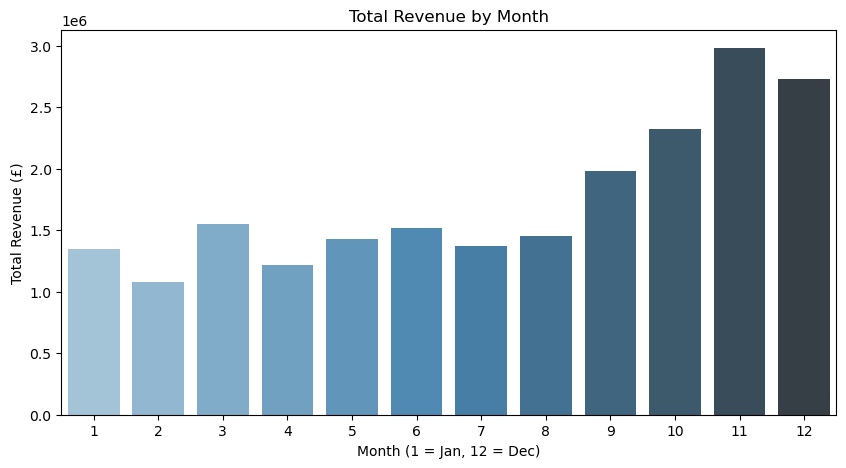

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reset index to make 'Month' a column
monthly_revenue = clean_data_df.groupby('Month')['Revenue'].sum().reset_index()

# 2. Plot total revenue by month
plt.figure(figsize=(10, 5))
sns.barplot(data=monthly_revenue, x='Month', y='Revenue', palette='Blues_d')
plt.title('Total Revenue by Month')
plt.xlabel('Month (1 = Jan, 12 = Dec)')
plt.ylabel('Total Revenue (£)')
plt.show()

In [51]:
daily_revenue = clean_data_df.groupby(['DayOfWeek'])['Revenue'].sum().reset_index()

In [52]:
daily_revenue.head()

,DayOfWeek,Revenue
0,0,3645130.156
1,1,4185862.912
2,2,3601790.373
3,3,4306392.172
4,4,3376979.183


C:\Users\araba\AppData\Local\Temp\ipykernel_35600\1813373178.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=daily_revenue, x='DayOfWeek', y='Revenue', palette='Blues_d')


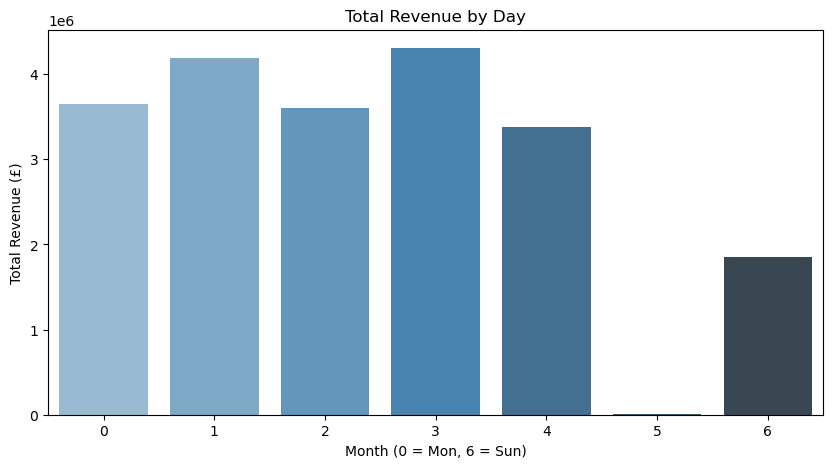

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

daily_revenue = clean_data_df.groupby(['DayOfWeek'])['Revenue'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=daily_revenue, x='DayOfWeek', y='Revenue', palette='Blues_d')
plt.title('Total Revenue by Day')
plt.xlabel('Month (0 = Mon, 6 = Sun)')
plt.ylabel('Total Revenue (£)')
plt.show()

In [56]:
filtered_view_df = clean_data_df[(clean_data_df['Quantity'] > 0) & (clean_data_df['Quantity'] < 100)]

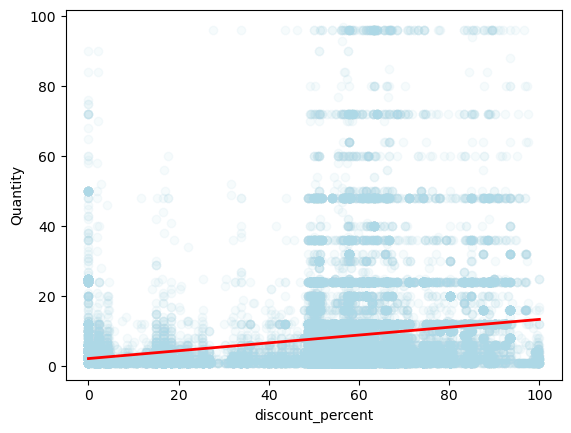

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 50k row sample for faster plotting
sample_df = filtered_view_df.sample(n=50000, random_state=42)

# Plotting the sample
sns.regplot(
    data=sample_df,
    x='discount_percent',
    y='Quantity',
    scatter_kws={'alpha': 0.1, 'color': 'lightblue'},
    line_kws={'color': 'red', 'linewidth': 2}
)
plt.show()

In [89]:
from sklearn.model_selection import train_test_split

# Define feature matrix X and target y
feature_cols = ["Price", "discount_percent", "Month", "DayOfWeek"]

X = clean_data_df[feature_cols]
y = clean_data_df["Quantity"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check the shape of the splits
print(f"Training rows: {X_train.shape[0]:,}")
print(f"Testing rows:  {X_test.shape[0]:,}")

Training rows: 833,336
Testing rows:  208,335


In [73]:
!pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   - -------------------------------------- 1.6/48.9 MB 8.7 MB/s eta 0:00:06
   -- ------------------------------------- 2.9/48.9 MB 7.3 MB/s eta 0:00:07
   --- ------------------------------------ 4.2/48.9 MB 7.1 MB/s eta 0:00:07
   ---- ----------------------------------- 5.5/48.9 MB 7.0 MB/s eta 0:00:07
   ----- ---------------------------------- 7.1/48.9 MB 7.1 MB/s eta 0:00:06
   ------- -------------------------------- 8.7/48.9 MB 7.1 MB/s eta 0:00:06
   -------- ------------------------------- 10.5/48.9 MB 7.2 MB/s eta 0:00:06
   --------- ------------------------------ 12.1/48.9 MB 7.3 MB/s eta 0:00:06
   ----------- ---------------------------- 13.6/48.9 MB 7.3 MB/s eta 0:00:05
   ------------ --------------------------- 15.2/48.9 MB 7.3 MB/s eta 0:00:05
   ------------- -------------------------- 16.8/48.9 MB 7.3 MB/s eta 0:00:05
   -------------- ------------------------- 18.1/48.9 MB 7.3 MB/s eta 0:00:05


In [90]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Instantiate the XGBoost Regressor
xgb_model = XGBRegressor(
    n_estimators=100,  # Number of boosting trees
    learning_rate=0.1,  # Step size shrinkage
    max_depth=6,  # Maximum tree depth
    random_state=42,
    n_jobs=-1,  # Use all available CPU cores
)

# Fit the model on training data
print("Training XGBoost model...")
xgb_model.fit(X_train, y_train)

# Predict on unseen test data
y_pred = xgb_model.predict(X_test)

# Evaluate performance metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} units")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} units")
print(f"R² Score (Variance Explained): {r2:.4f}")

Training XGBoost model...

--- Model Evaluation Metrics ---
Mean Absolute Error (MAE): 8.61 units
Root Mean Squared Error (RMSE): 70.89 units
R² Score (Variance Explained): 0.2941


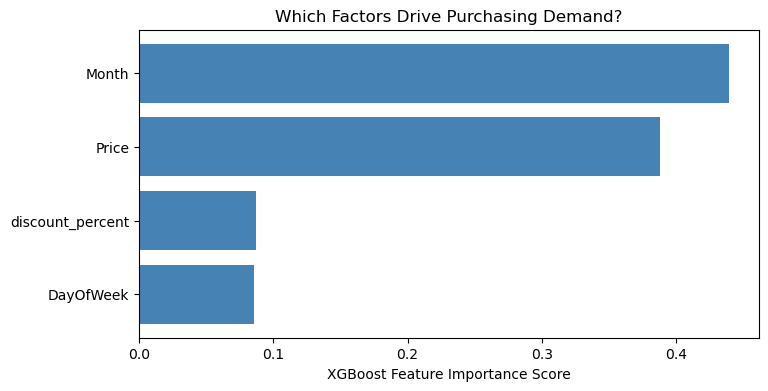

In [91]:
import matplotlib.pyplot as plt
import pandas as pd

# Plot feature importances
importance_df = pd.DataFrame(
    {"Feature": X.columns, "Importance": xgb_model.feature_importances_}
).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="steelblue")
plt.xlabel("XGBoost Feature Importance Score")
plt.title("Which Factors Drive Purchasing Demand?")
plt.gca().invert_yaxis()
plt.show()

In [92]:
import pandas as pd

# 1. Create 1 row of fake data to test
test_scenario = pd.DataFrame(
    [{"Price": 10.0, "discount_percent": 10.0, "Month": 11, "DayOfWeek": 2}]
)

# 2. Ask your model to predict Quantity
predicted_qty = xgb_model.predict(test_scenario)[0]
print(f"At £10, predicted sales = {predicted_qty:.1f} units")

# 3. Calculate revenue yourself in Python
revenue = 10.0 * predicted_qty
print(f"Total Revenue = £{revenue:.2f}")

At £10, predicted sales = 2.3 units
Total Revenue = £22.95
